# Full Hybrid CNN+LSTM+GRU Dysarthria Notebook

## 1. Imports

In [ ]:

import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.utils import to_categorical


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Load File Paths (00000= Non-Dys, 11111 = Dys)

In [ ]:

BASE_PATH = "/content/drive/MyDrive"
NON_DYS_PATH = os.path.join(BASE_PATH, "00000")
DYS_PATH = os.path.join(BASE_PATH, "11111")

file_paths = []
labels = []

for f in os.listdir(NON_DYS_PATH):
    if f.endswith(".wav"):
        file_paths.append(os.path.join(NON_DYS_PATH, f))
        labels.append(0)

for f in os.listdir(DYS_PATH):
    if f.endswith(".wav"):
        file_paths.append(os.path.join(DYS_PATH, f))
        labels.append(1)

file_paths = np.array(file_paths)
labels = np.array(labels)

print("Total files:", len(file_paths))


Total files: 799


## 3. Mel Spectrogram Extraction (Fixed Length)

In [ ]:

TARGET_SR = 16000
DURATION = 3.0
MAX_SAMPLES = int(TARGET_SR * DURATION)
N_FFT = 1024
HOP_LENGTH = 256
N_MELS = 64

def extract_mel_fixed(wav_path):
    y, sr = librosa.load(wav_path, sr=TARGET_SR)

    if len(y) < MAX_SAMPLES:
        y = np.pad(y, (0, MAX_SAMPLES - len(y)))
    else:
        y = y[:MAX_SAMPLES]

    mel = librosa.feature.melspectrogram(
        y=y, sr=TARGET_SR,
        n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return mel_db


## 4. Generate Features

In [ ]:

X = []

for fp in file_paths:
    mel = extract_mel_fixed(fp)
    X.append(mel)

X = np.array(X)
print("Feature shape:", X.shape)


Feature shape: (799, 64, 188)


## 5. Normalize & Reshape

In [ ]:

X = (X - np.mean(X)) / (np.std(X) + 1e-8)
X = X[..., np.newaxis]

y_cat = to_categorical(labels, 2)

print(X.shape, y_cat.shape)


(799, 64, 188, 1) (799, 2)


## 6. Train / Val / Test Split (70/15/15)

In [ ]:

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_cat, test_size=0.30, random_state=42, stratify=labels
)

y_temp_lbls = np.argmax(y_temp, axis=1)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp_lbls
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)


Train: (559, 64, 188, 1)
Val: (120, 64, 188, 1)
Test: (120, 64, 188, 1)


# Visualize Melspectogram

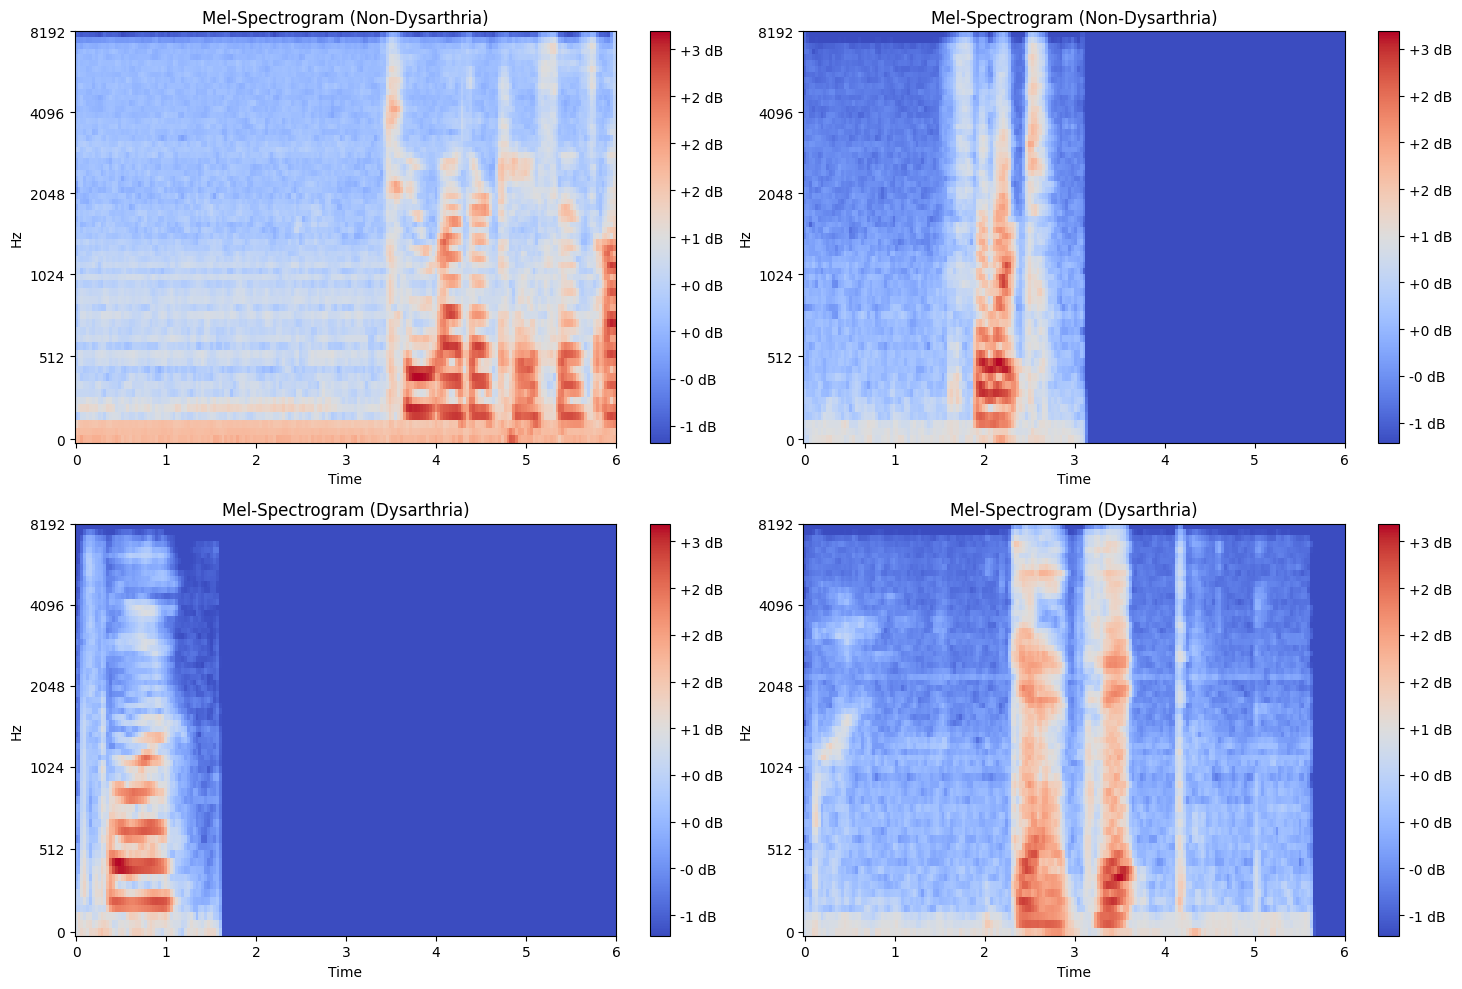

In [ ]:
import matplotlib.pyplot as plt
import librosa.display
import numpy as np

def trim_silence_for_plot(mel, energy_threshold=-60):
    frame_energy = np.mean(mel, axis=0)
    non_silent = np.where(frame_energy > energy_threshold)[0]

    if len(non_silent) == 0:
        return mel[:, :1]

    return mel[:, non_silent[0]: non_silent[-1] + 1]

y_train_lbls = np.argmax(y_train, axis=1)

dysarthria_indices = [i for i, label in enumerate(y_train_lbls) if label == 1]
non_dysarthria_indices = [i for i, label in enumerate(y_train_lbls) if label == 0]

sample_indices = {
    "Non-Dysarthria": non_dysarthria_indices[:2],
    "Dysarthria": dysarthria_indices[:2]
}

plt.figure(figsize=(15, 10))
i = 0

for label_type, indices in sample_indices.items():
    for idx in indices:
        plt.subplot(2, 2, i + 1)

        mel = X_train[idx].squeeze()
        mel = trim_silence_for_plot(mel)

        librosa.display.specshow(
            mel,
            sr=16000,
            x_axis='time',
            y_axis='mel'
        )

        plt.colorbar(format='%+2.0f dB')
        plt.title(f"Mel-Spectrogram ({label_type})")
        plt.tight_layout()
        i += 1

plt.show()


## 7. Hybrid CNN + LSTM + GRU Model

In [ ]:
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Dropout,
    BatchNormalization, Reshape,
    LSTM, GRU, Dense, Concatenate
)
from tensorflow.keras.models import Model

inputs = Input(shape=(X_train.shape[1], X_train.shape[2], 1))


x = Conv2D(32, (3,3), padding='same', activation='relu')(inputs)
x = MaxPooling2D((2,2))(x)

x = Conv2D(64, (3,3), padding='same', activation='relu')(x)
x = MaxPooling2D((2,2))(x)


time_steps = x.shape[2]
features = x.shape[1] * x.shape[3]
x_seq = Reshape((time_steps, features))(x)


lstm_out = LSTM(64)(x_seq)
gru_out  = GRU(64)(x_seq)


fusion = Concatenate()([lstm_out, gru_out])


fc = Dense(64, activation='relu')(fusion)

outputs = Dense(2, activation='softmax')(fc)

hybrid_model = Model(inputs, outputs)

hybrid_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

hybrid_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 188,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 188,   │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 94,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 94,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 47,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 47, 1024)  │          0 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │    278,784 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 64)        │    209,280 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128)       │          0 │ lstm[0][0],       │
│ (Concatenate)       │                   │            │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 2)         │        130 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 515,266 (1.97 MB)

 Trainable params: 515,266 (1.97 MB)

 Non-trainable params: 0 (0.00 B)

## 8. Training

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history = hybrid_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=16,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 21s 421ms/step - accuracy: 0.5599 - loss: 0.6540 - val_accuracy: 0.6667 - val_loss: 0.5836 - learning_rate: 0.0010
Epoch 2/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 14s 400ms/step - accuracy: 0.7263 - loss: 0.5319 - val_accuracy: 0.6667 - val_loss: 0.5381 - learning_rate: 0.0010
Epoch 3/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 21s 404ms/step - accuracy: 0.7424 - loss: 0.4948 - val_accuracy: 0.7583 - val_loss: 0.5279 - learning_rate: 0.0010
Epoch 4/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 20s 376ms/step - accuracy: 0.7853 - loss: 0.4359 - val_accuracy: 0.8250 - val_loss: 0.4271 - learning_rate: 0.0010
Epoch 5/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 14s 402ms/step - accuracy: 0.8318 - loss: 0.3742 - val_accuracy: 0.7917 - val_loss: 0.4283 - learning_rate: 0.0010
Epoch 6/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 21s 419ms/step - accuracy: 0.8515 - loss: 0.3198 - val_accuracy: 0.8417 - val_loss: 0.3827 - learning_rate: 0.0010
Epoch 7/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 17s 500ms/step - accuracy: 0.8855 - loss: 0.

## 9. Evaluation on Test Set

In [ ]:

test_loss, test_acc = hybrid_model.evaluate(X_test, y_test, verbose=1)
print("Test Accuracy:", test_acc)

y_pred = np.argmax(hybrid_model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

print("Classification Report:")
print(classification_report(y_true, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 291ms/step - accuracy: 0.9333 - loss: 0.2218
Test Accuracy: 0.9333333373069763
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 500ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94        60
           1       0.96      0.90      0.93        60

    accuracy                           0.93       120
   macro avg       0.94      0.93      0.93       120
weighted avg       0.94      0.93      0.93       120

Confusion Matrix:
[[58  2]
 [ 6 54]]


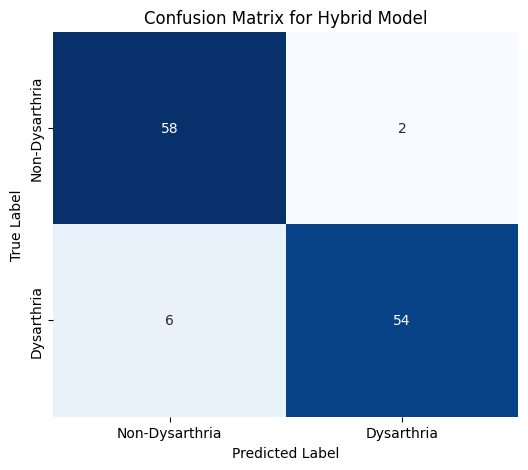

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non-Dysarthria', 'Dysarthria'],
            yticklabels=['Non-Dysarthria', 'Dysarthria'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Hybrid Model')
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step


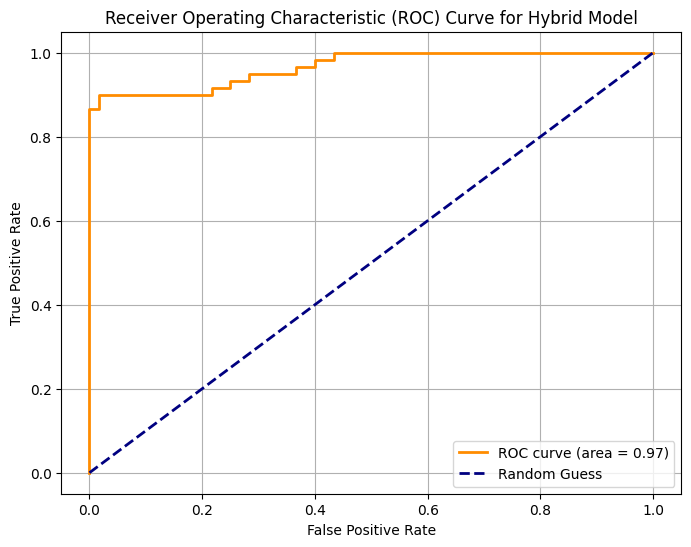

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_pred_proba = hybrid_model.predict(X_test)

fpr, tpr, thresholds = roc_curve(y_test[:, 1], y_pred_proba[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Hybrid Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

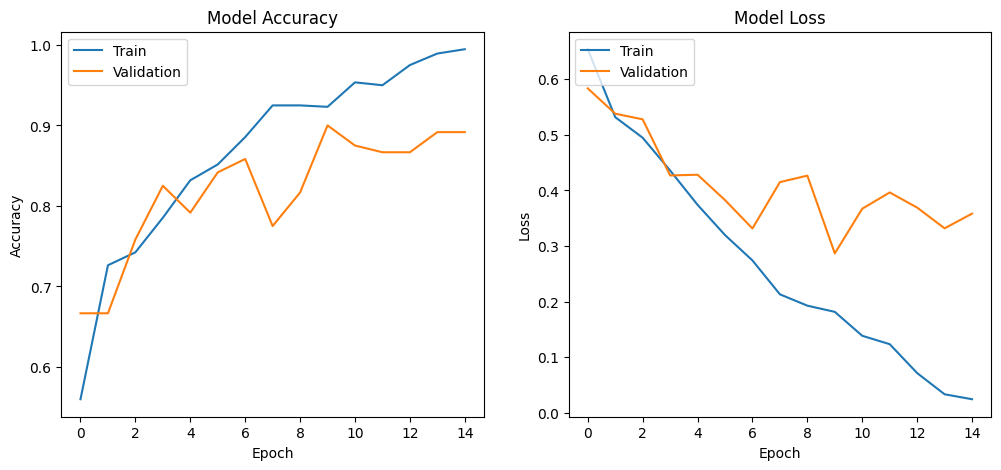

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()